# Foveation: Spatially-Varying Blur

The human retina has a small central region called the **fovea** containing the highest density of cone photoreceptors. Spatial acuity drops sharply with eccentricity (distance from the fixation point): resolution at 10° eccentricity is roughly 1/10th of foveal resolution.

## Spatially-varying Gaussian blur

A **foveated image** simulates this acuity falloff by applying a Gaussian blur whose standard deviation grows with distance from the gaze point $\mathbf{m} = (m_x, m_y)$:
$$
\sigma(x, y; \mathbf{m}, s) = \sigma_{\max} \bigl(1 - e^{-\|\mathbf{x} - \mathbf{m}\|^2 / (2s^2)}\bigr),
$$
so $\sigma \to 0$ near the fixation point and $\sigma \to \sigma_{\max}$ far away.

## Implementation via a blur stack

Direct per-pixel blurring is expensive. An efficient approach builds a **blur stack**: a set of images blurred at $p$ discrete levels $\sigma_1 < \sigma_2 < \cdots < \sigma_p$. For each pixel $(x, y)$ the blur level
$$
\ell(x, y) = \text{round}\bigl((p-1)\,(1 - e^{-\|\mathbf{x}-\mathbf{m}\|^2/(2s^2)})\bigr) + 1
$$
selects which level to sample, reducing $O(n^2)$ convolutions to $O(p)$ convolutions followed by $O(n^2)$ table lookups.

## Connections

- **Gaze-contingent rendering**: foveated rendering in VR/AR exploits eye-tracking to reduce GPU load — only the foveal region needs full resolution.
- **Scale-space theory**: the blur stack is a sampled scale-space pyramid $L(x, y, \sigma) = g_\sigma * f$.
- **Perceptual image compression**: foveated wavelet coders allocate more bits near the fixation point.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

plt.rcParams['figure.dpi'] = 120

## Building the blur stack

We generate a synthetic test image (radial gradient with embedded structure) and compute $p$ Gaussian-blurred versions at increasing $\sigma$. All convolutions are done via FFT.

In [2]:
n = 256
t = np.linspace(-1, 1, n)
Y, X = np.meshgrid(t, t)

# Synthetic test image: sinusoidal texture on a smooth background
rng = np.random.default_rng(42)
f = 0.4 * np.sin(12 * np.pi * X) * np.sin(10 * np.pi * Y) \
  + 0.3 * np.cos(20 * np.pi * (X + 0.3*Y)) \
  + 0.3 * (1 - X**2 - Y**2)
f = np.clip(f, 0, 1)

# FFT-based Gaussian blur
tx = np.fft.fftfreq(n) * n
TY, TX = np.meshgrid(tx, tx)

def gauss_blur(f, sigma):
    if sigma < 1e-8:
        return f.copy()
    kernel = np.exp(-2 * np.pi**2 * sigma**2 * (TX**2 + TY**2) / n**2)
    return np.real(np.fft.ifft2(np.fft.fft2(f) * kernel))

# Build blur stack
p = 40
sigma_max = 18.0
sigma_list = np.linspace(0, sigma_max, p)
stack = np.stack([gauss_blur(f, s) for s in sigma_list], axis=2)  # shape (n, n, p)

print(f'Blur stack shape: {stack.shape}')

Blur stack shape: (256, 256, 40)


## The foveation function

Given a gaze point $(m_x, m_y)$ and falloff scale $s$, we build the blur-level map $\ell(x,y)$, then index into the stack. The lookup selects, pixel by pixel, the blurred image at the appropriate level.

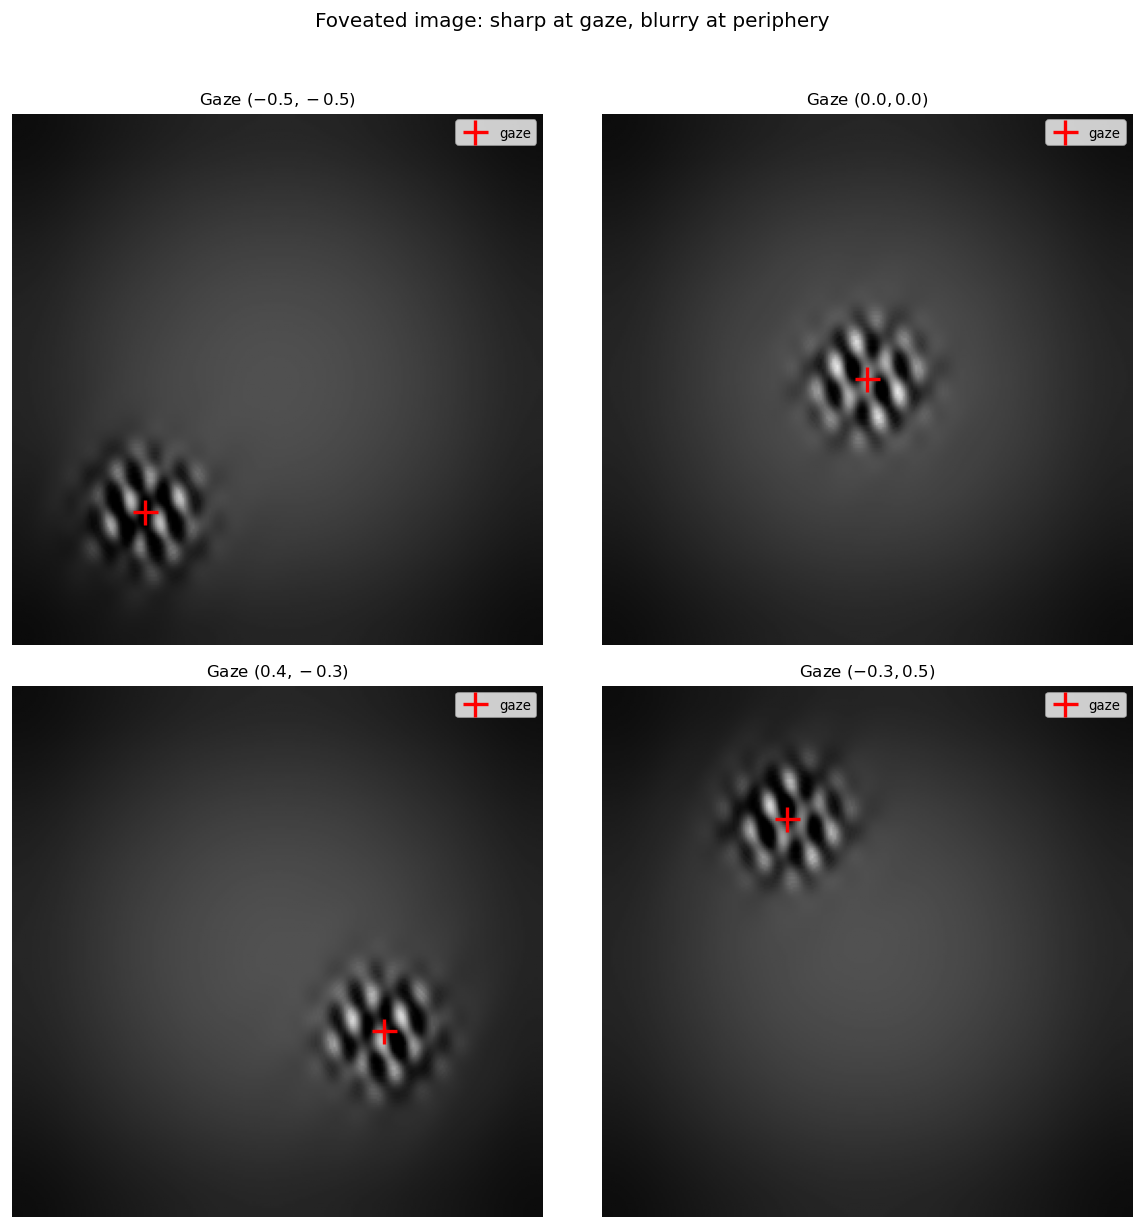

In [3]:
def foveate(f_stack, sigma_list, gaze_x=0.0, gaze_y=0.0, falloff=0.3):
    """Foveated image: sharp at gaze, blurred at periphery."""
    p = f_stack.shape[2]
    dist2 = (X - gaze_x)**2 + (Y - gaze_y)**2
    blur_weight = 1.0 - np.exp(-dist2 / (2 * falloff**2))
    level = np.round(blur_weight * (p - 1)).astype(int)
    level = np.clip(level, 0, p-1)
    # Pixel-wise lookup
    ii, jj = np.mgrid[0:n, 0:n]
    return f_stack[ii, jj, level]

# Display foveation at a fixed gaze point
gaze_pts = [(-0.5, -0.5), (0.0, 0.0), (0.4, -0.3), (-0.3, 0.5)]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, (gx, gy) in zip(axes.ravel(), gaze_pts):
    g = foveate(stack, sigma_list, gaze_x=gx, gaze_y=gy, falloff=0.35)
    ax.imshow(g.T, extent=[-1,1,-1,1], origin='lower', cmap='gray',
              vmin=0, vmax=1)
    ax.plot(gx, gy, 'r+', ms=15, mew=2, label='gaze')
    ax.set_title(f'Gaze $({gx:.1f}, {gy:.1f})$', fontsize=10)
    ax.legend(fontsize=8); ax.axis('off')

fig.suptitle('Foveated image: sharp at gaze, blurry at periphery', y=1.02)
plt.tight_layout()
plt.show()

## Blur-level map visualization

The blur-level map $\ell(x,y)$ shows how the selected blur level varies across the image. Near the gaze it is 0 (original), growing radially toward the maximum level.

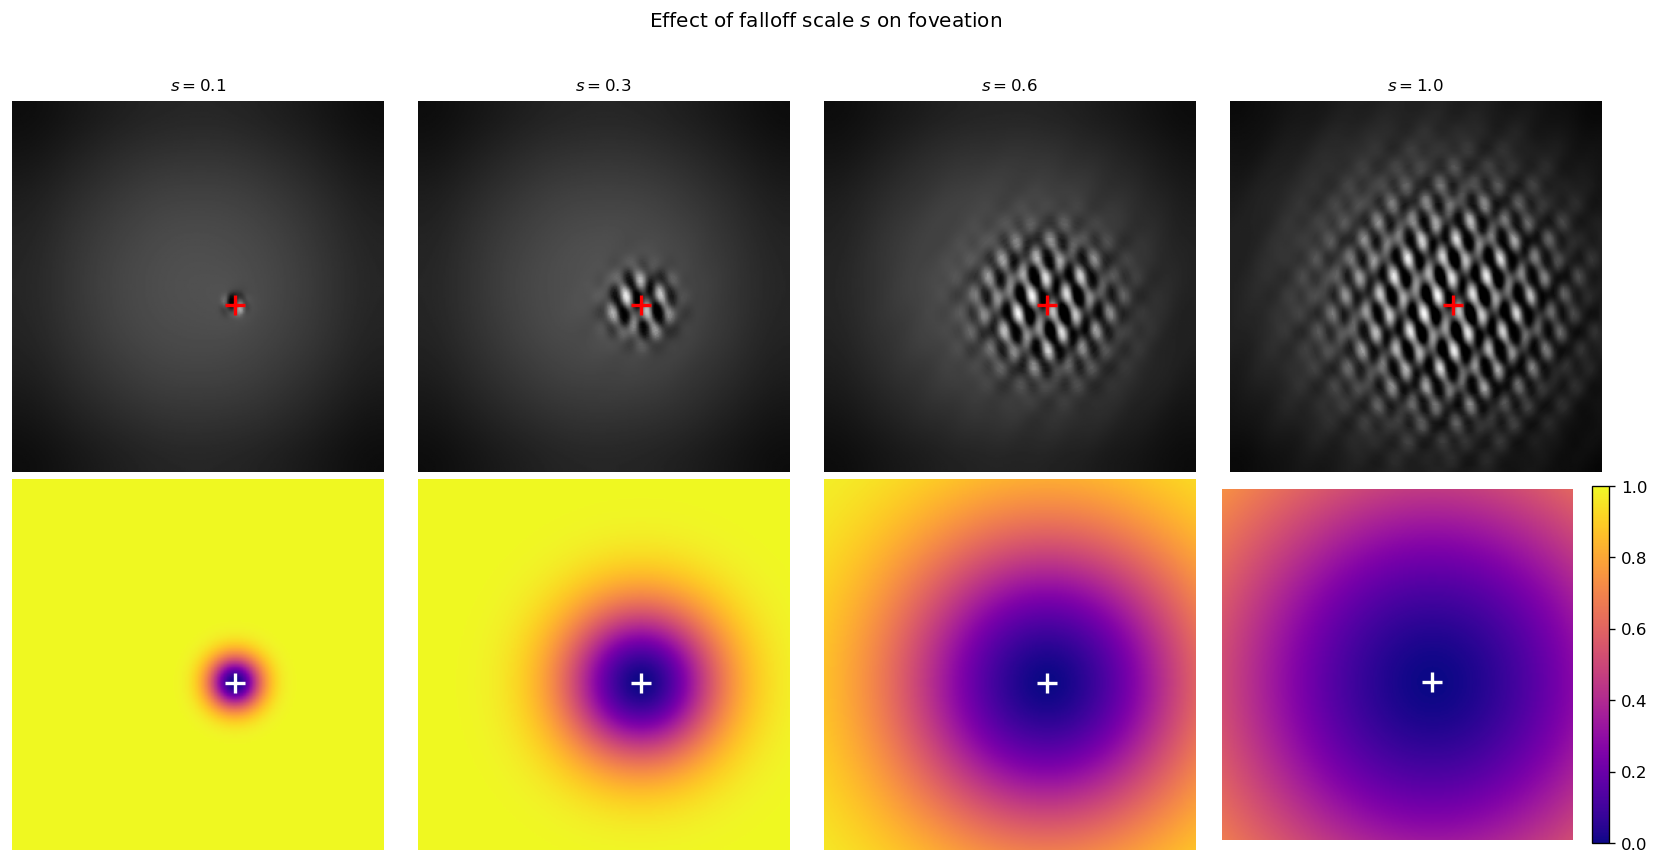

In [4]:
gx, gy = 0.2, -0.1
falloff_vals = [0.1, 0.3, 0.6, 1.0]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for col, s in enumerate(falloff_vals):
    g = foveate(stack, sigma_list, gaze_x=gx, gaze_y=gy, falloff=s)
    dist2 = (X - gx)**2 + (Y - gy)**2
    level_map = 1 - np.exp(-dist2 / (2 * s**2))

    axes[0, col].imshow(g.T, extent=[-1,1,-1,1], origin='lower',
                        cmap='gray', vmin=0, vmax=1)
    axes[0, col].plot(gx, gy, 'r+', ms=12, mew=2)
    axes[0, col].set_title(f'$s={s}$', fontsize=10); axes[0, col].axis('off')

    im = axes[1, col].imshow(level_map.T, extent=[-1,1,-1,1], origin='lower',
                             cmap='plasma', vmin=0, vmax=1)
    axes[1, col].plot(gx, gy, 'w+', ms=12, mew=2)
    axes[1, col].axis('off')
    if col == 3:
        plt.colorbar(im, ax=axes[1, col], fraction=0.046)

axes[0, 0].set_ylabel('foveated image', fontsize=9)
axes[1, 0].set_ylabel('blur level map', fontsize=9)
fig.suptitle('Effect of falloff scale $s$ on foveation', y=1.02)
plt.tight_layout()
plt.show()

## Interactive: move the gaze point

Drag the sliders to simulate moving the fixation point across the image while adjusting the falloff scale.

In [5]:
def show_foveation(gaze_x=0.0, gaze_y=0.0, falloff=0.3):
    g = foveate(stack, sigma_list, gaze_x=gaze_x, gaze_y=gaze_y, falloff=falloff)
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    axes[0].imshow(f.T, extent=[-1,1,-1,1], origin='lower',
                   cmap='gray', vmin=0, vmax=1)
    axes[0].plot(gaze_x, gaze_y, 'r+', ms=15, mew=2)
    axes[0].set_title('Original image + gaze'); axes[0].axis('off')

    axes[1].imshow(g.T, extent=[-1,1,-1,1], origin='lower',
                   cmap='gray', vmin=0, vmax=1)
    axes[1].plot(gaze_x, gaze_y, 'r+', ms=15, mew=2)
    axes[1].set_title(fr'Foveated ($s={falloff:.2f}$)'); axes[1].axis('off')
    plt.tight_layout(); plt.show()

interact(show_foveation,
         gaze_x=FloatSlider(value=0.0, min=-0.8, max=0.8, step=0.05,
                            description='gaze $x$'),
         gaze_y=FloatSlider(value=0.0, min=-0.8, max=0.8, step=0.05,
                            description='gaze $y$'),
         falloff=FloatSlider(value=0.3, min=0.05, max=0.8, step=0.05,
                             description='falloff $s$'));

interactive(children=(FloatSlider(value=0.0, description='gaze $x$', max=0.8, min=-0.8, step=0.05), FloatSlide…

## Bibliographical resources

- Geisler, W. S. and Perry, J. S. (1998). Real-time foveated multiresolution system for low-bandwidth video communication. *Proceedings of SPIE*, 3299, 294–305.
- Lindeberg, T. (1994). *Scale-Space Theory in Computer Vision*. Kluwer Academic Publishers.
- Guenter, B., Finch, M., Drucker, S., Tan, D. and Snyder, J. (2012). Foveated 3D graphics. *ACM Transactions on Graphics*, 31(6), Article 164.
- Watson, A. B. and Ahumada, A. J. (2016). The pyramid of visibility. *Proceedings of Human Vision and Electronic Imaging*, IS&T.
- Weiss, Y. and Simoncelli, E. P. (2002). Fast maximum a posteriori estimation with neural architectures. *Advances in Neural Information Processing Systems*, 14.